<a href="https://colab.research.google.com/github/Sina-Haz/fastai-pt-2/blob/main/Diff_Edit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Implementing DiffEdit

The [DiffEdit]() paper introduces a novel method to edit images with diffusion models.

In this notebook we will try to implement it using stable diffusion

In [ ]:
import torch
from torchvision import transforms as tfms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from fastdownload import FastDownload
from tqdm.auto import tqdm

if torch.cuda.is_available():
    # Shows the nvidia GPUs, if this system has any
    !nvidia-smi

Fri Aug  8 13:36:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             33W /   70W |    6368MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
save_dir = '/content/drive/MyDrive/stable-diffusion' # where I saved the model so I can load faster

In [ ]:
from diffusers import StableDiffusionPipeline

# Loading in the whole pipeline at once
pipe = StableDiffusionPipeline.from_pretrained(save_dir, torch_dtype=torch.float16)

In [ ]:
if torch.cuda.is_available():
    device=torch.device("cuda")
elif torch.backends.mps.is_available():
    device=torch.device("mps")

pipe.to(device) # move to the gpu

In [ ]:
from diffusers import DDIMScheduler

# Grab the components
vae = pipe.vae
unet = pipe.unet
tokenizer = pipe.tokenizer
text_enc = pipe.text_encoder
# Import to use DDIMScheduler here as it doesn't keep internal state about what timestep it's on
scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", clip_sample=False, set_alpha_to_one=False)

In [ ]:
# Firstly we will bring over some helper functions from our previous notebook where we implemented the
# stable diffusion pipeline:

def enc_text(prompts, maxlen=None):
  # Pad up to maxlen (if None defaults to model max len), truncate if prompt is too long
  inp = tokenizer(prompts, padding="max_length", max_length=maxlen, truncation=True, return_tensors="pt")
  return text_enc(inp.input_ids.to("cuda"))[0].half()

def to_img(latents):
  dec = vae.decode(1 / 0.18215 * latents).sample
  img = (dec/2 + 0.5).clamp(0, 1).detach().cpu().permute(0, 2, 3, 1).numpy()
  rescaled = (img * 255).round().astype("uint8")
  return [Image.fromarray(image) for image in rescaled]

def to_latent(img):
  ten = tfms.ToTensor()(img).unsqueeze(0) * 2.0 - 1.0
  ten= ten.to(device, dtype=torch.float16)
  with torch.no_grad(): latent = vae.encode(ten).latent_dist.sample() * 0.18215
  return latent

def load_image(p):
  img = Image.open(p).convert("RGB")
  img = img.resize((512, 512))
  return img


def diff_loop(sched, latents, emb, ts, g):
  # Scale the model input based on scheduler
  inp = sched.scale_model_input(torch.cat([latents] * 2), ts)
  with torch.no_grad():
    u, t = unet(inp, ts, encoder_hidden_states=emb).sample.chunk(2) # Use unet to predict noise (conditioned over embedding)
  pred = u + g*(t-u) # classifier free guidance
  return pred

In [ ]:
# Download and view our image
p = FastDownload().download('https://images.pexels.com/photos/1996333/pexels-photo-1996333.jpeg?cs=srgb&dl=pexels-helena-lopes-1996333.jpg&fm=jpg&_gl=1*1pc0nw8*_ga*OTk4MTI0MzE4LjE2NjY1NDQwMjE.*_ga_8JE65Q40S6*MTY2Njc1MjIwMC4yLjEuMTY2Njc1MjIwMS4wLjAuMA..')
init_img = load_image(p)
init_img

### Step 1: Creating a Mask

Given two different text queries (one being the original and the other being the edited image), the diffusion model will yield different noise estimates.

1. We add noise to the original image

2. Estimate the noises over both queries

3. Compute normalized difference and binarize into a mask


Steps 1 and 2 can be combined and thought of an "Image to Image" stable diffusion generation
 - Authors of the paper recommend a strength of 50% for the noise added to the original image before denoising

From there, we can complete step 3
 - the authors of the paper recommend us to repeat this n=10 times and average the differences to make 1 mask

In [ ]:
t = int(0.5 * 50)
scheduler.timesteps[-t]

In [ ]:
# Creating image to image pipeline
# We use strength * n steps to determine how many steps of forward diffusion we do on initial image
# So if strength = 1 -> complete noise, strength=0 -> original image with no added noise
def im2im(init_img, prompt, g = 7.5, strength = 0.5, steps=50, seed=100):
  if seed: torch.manual_seed(seed)
  # Convert the initial image to latent representation
  ltnt = to_latent(init_img)

  # Set the timesteps of the scheduler:
  scheduler.set_timesteps(steps)

  t_init = int(strength * steps)
  # move t steps backwards (b/c scheduler.timesteps goes from full noise to 0 noise)
  t = torch.tensor([scheduler.timesteps[-t_init]], device=device)

  # Now we add noise to the latents to get our starting point
  noised_ltnt = scheduler.add_noise(ltnt, torch.randn_like(ltnt), t)
  # Compute where in the diffusion process to start based on timestep computed above
  start = max(steps - t_init, 0)
  timesteps = scheduler.timesteps[start:].to(device)

  # We also get our text embeddings for prompt (using classifier-free guidance)
  txt = enc_text(prompt)
  uncond = enc_text("")
  emb = torch.cat([uncond, txt])

  # Run the diffusion loop
  for i, ts in tqdm(enumerate(timesteps), total=len(timesteps)):
    pred = diff_loop(scheduler, noised_ltnt, emb, ts, g)
    noised_ltnt = scheduler.step(pred, ts, noised_ltnt).prev_sample

  return noised_ltnt


  0%|          | 0/35 [00:00<?, ?it/s]

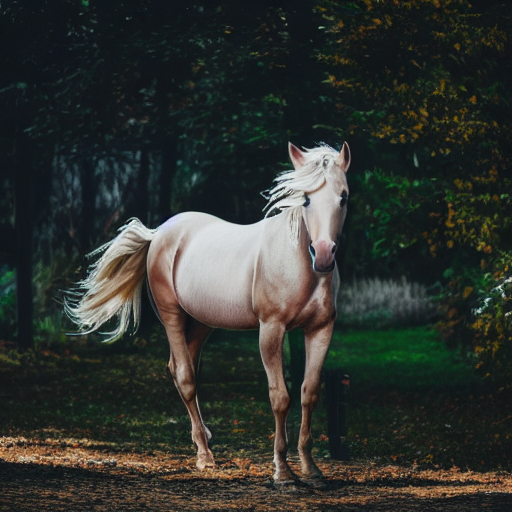

In [ ]:
ltnts = im2im(init_img, prompt='A brown horse', strength = 0.7)
to_img(ltnts)[0]

In [ ]:
# Now, using this image 2 image pipeline which we have just implemented, we can write a function to
# Create the mask for diff edit, all we need to do is for n times repeat:
# Take the original image and use im2im with both the reference prompt and query prompt
# Take the difference between these 2

ref_ltnt = im2im(init_img, prompt = 'a horse image')
query_ltnt = im2im(init_img, prompt = 'a zebra image')

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
diff = (ref_ltnt - query_ltnt).detach().cpu().numpy()

# Linear normalization:
# subtract the min so everything is positive then divide by the size of the interval
scaled = (diff - diff.min()) / (diff.max() - diff.min())

((scaled > 1) | (scaled < 0)).sum()

np.int64(0)

In [ ]:
avg = scaled[0].mean(0) # take out batch dimension and average over channels

avg.shape, avg

((64, 64),
 array([[0.4822, 0.4858, 0.4722, ..., 0.4897, 0.477 , 0.475 ],
        [0.477 , 0.481 , 0.4973, ..., 0.4717, 0.475 , 0.481 ],
        [0.4849, 0.4866, 0.4854, ..., 0.504 , 0.479 , 0.491 ],
        ...,
        [0.4832, 0.48  , 0.4854, ..., 0.4543, 0.4817, 0.4565],
        [0.4807, 0.479 , 0.496 , ..., 0.4883, 0.4907, 0.4756],
        [0.482 , 0.4731, 0.483 , ..., 0.4817, 0.4634, 0.481 ]],
       dtype=float16))

In [ ]:
def plot_mask(mask):
  plt.imshow(np.array(init_img), cmap='gray') # I would add interpolation='none'
  plt.imshow(
      Image.fromarray(mask).resize((512,512)), ## Scaling the mask to original size
      cmap='cividis',
      alpha=0.5*(np.array(Image.fromarray(mask*255).resize((512,512))) > 0)
  );

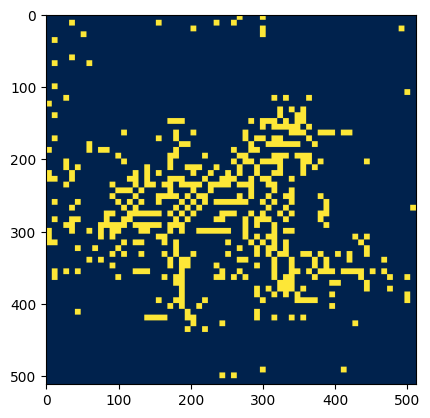

In [ ]:
# So the way that the paper recommends making masks is through this scaling and then applying >0.5 to binarize
m1 = (avg > 0.5).astype("uint8")
plot_mask(m1)

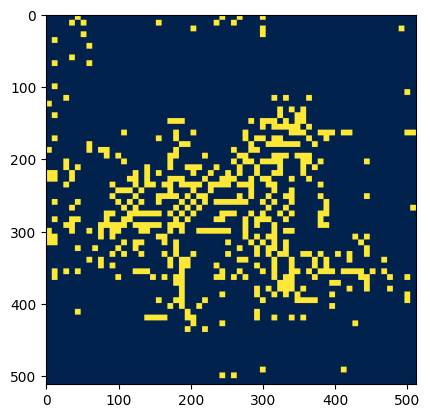

In [ ]:
# Another way to create the mask is to standardize the difference and then check for pixels which are > 0
scaled2 = (diff - diff.mean()) / np.std(diff)

avg2 = scaled2[0].mean(0)

m2 = (avg2 > 0.3).astype("uint8")
plot_mask(m2) # 0 gave too non-specific of a mask but might be better once we average

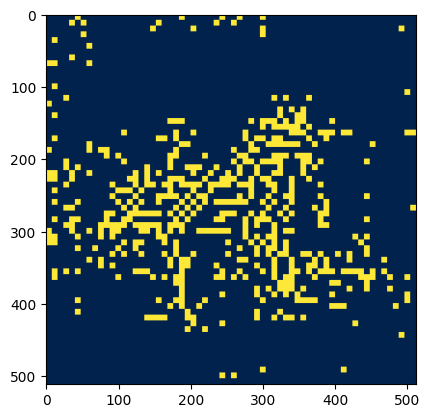

In [ ]:
# Try averaging channels before normalization:
avg_diff = diff[0].mean(0)

scaled3 = (avg_diff - avg_diff.mean()) / np.std(avg_diff)

m3 = (scaled3 > 0.5).astype("uint8")

plot_mask(m3) # Very similar result as to above

In [ ]:
def create_mask(init_img, rp, qp, n=10, s=0.5):
    ## Initialize a dictionary to save n iterations
    diffs = []

    ## Repeating the difference process n times
    for idx in range(n):
      # NOTE: really important that the seed for the im2im of both of these is the same
      # This ensures that the "seed" or starting point of them is both the same so that their differences
      # ONLY have to do with the different text conditioning and not the random noise being different
        ## Creating denoised sample using reference / original text
        orig_noise = im2im(init_img, rp, strength=s, seed = 100*idx)[0].detach().cpu()
        ## Creating denoised sample using query / target text
        query_noise = im2im(init_img, qp, strength=s, seed = 100*idx)[0].detach().cpu()
        ## Taking the difference
        diffs.append(np.array(orig_noise)-np.array(query_noise))

    ## Creating a mask placeholder
    mask = np.zeros_like(diffs[0])

    ## Taking an average of 10 iterations
    for idx in range(n):
        ## Note np.abs is a key step
        mask += np.abs(diffs[idx]) # add the absolute difference s.t. when we filter the mask only keeps cell with positive abs diff
    mask /= n

    ## Averaging multiple channels
    mask = mask.mean(0)

    ## Normalizing
    mask = (mask - mask.mean()) / np.std(mask)

    ## Binarizing and returning the mask object
    return (mask > 0.2).astype("uint8")

m = create_mask(init_img, ['a horse image'], ['a zebra image'], n=5)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

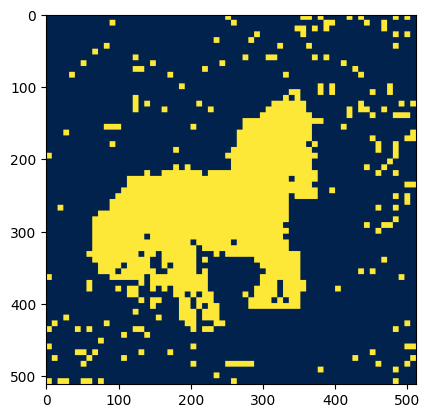

In [ ]:
plot_mask(m) # We finally got a super accurate mask

Step 2. Masked Diffusion

Once we have a solid mask which tells us which part of the picture we want to focus our edits on we:
1. Encode the image, i.e. add gaussian noise up to some "strength"
2. Decode the image via diffusion using the following equation: $$\hat y_t = My_t + (1-M)x_t$$

this equation simply means that for the masked portion of the image we compute noise estimate conditioned on the query, for the other portion we compute noise estimate based on the reference.

This idea is illustrated via the following figure from the paper in a bit more depth: ![](https://miro.medium.com/v2/resize:fit:1400/format:webp/0*oAgHGBoneVPAJLOY.png)

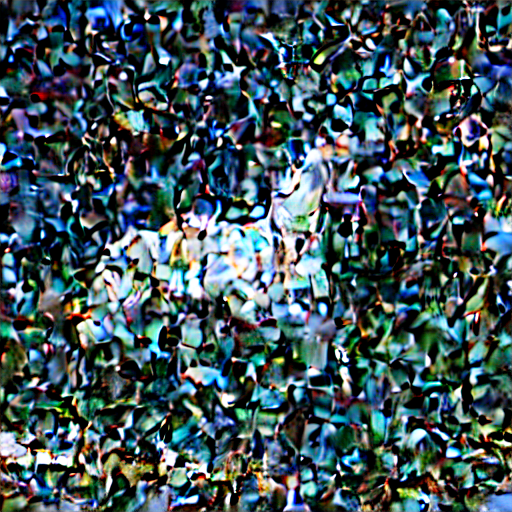

In [ ]:
# lets do part 1: convert our image into a latent and noise it up to some step r (r based on strength)
# Get latent plus params
ltnt = to_latent(init_img)
steps, strength = 70, 0.5 # Showing with low strength so you can still see the general picture

# Set the timesteps of the scheduler:
scheduler.set_timesteps(steps)
t_init = int(strength * steps)
t = torch.tensor([scheduler.timesteps[-t_init]], device=device)

# Now we add noise to the latents to get our starting point
noised_ltnt = scheduler.add_noise(ltnt, torch.randn_like(ltnt), t)

to_img(noised_ltnt)[0]

In [ ]:
# Now we need to write a custom "masked diffusion"
# Setup our embeddings and such here

# Compute where in the diffusion process to start based on timestep computed above
start = max(steps - t_init, 0)
timesteps = scheduler.timesteps[start:].to(device)
guidance=7.5

# We also get our text embeddings for prompt (using classifier-free guidance)
rtxt = enc_text('horse image')
qtxt = enc_text('zebra image')
uncond = enc_text("")

emb = torch.cat([uncond, rtxt, qtxt])
torch.manual_seed(42);

In [ ]:
m[None, None, ...].shape, noised_ltnt.shape # shapes match for broadcasting

((1, 1, 64, 64), torch.Size([1, 4, 64, 64]))

  0%|          | 0/35 [00:00<?, ?it/s]

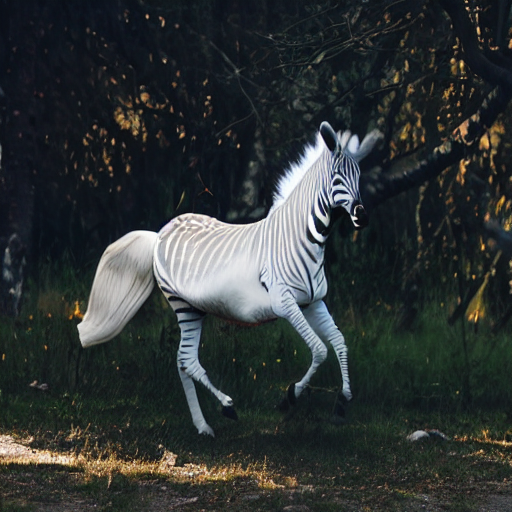

In [ ]:
# Need mask to be a torch tensor on device
mask = torch.tensor(m[None, None, ...], device=device)

# Here is the loop:
for i, ts in tqdm(enumerate(timesteps), total=len(timesteps)):
  inp = scheduler.scale_model_input(torch.cat([noised_ltnt] * 3), ts)

  with torch.no_grad():
    u, rt, qt = unet(inp, ts, encoder_hidden_states=emb).sample.chunk(3)

  # Guidance
  rpred = u + guidance*(rt-u)
  qpred = u + guidance*(qt-u)

  # Get both latents, important to use the DDIM scheduler here or will run into out of bounds error
  rltnt = scheduler.step(rpred, ts, noised_ltnt).prev_sample
  qltnt = scheduler.step(qpred, ts, noised_ltnt).prev_sample

  # Combine using mask
  noised_ltnt = mask*qltnt + (1-mask)*rltnt

to_img(noised_ltnt)[0] # Looks like it works!!!

In [ ]:
# Now let's put all this into a function
def masked_diffusion(init_img, mask, rp, qp, steps=70, strength=0.5, guidance=7.5, seed=100):
  ltnt = to_latent(init_img)

  # Set the timesteps of the scheduler:
  scheduler.set_timesteps(steps)
  t_init = int(strength * steps)
  t = torch.tensor([scheduler.timesteps[-t_init]], device=device) # This is the noise level

  # Now we add noise to the latents to get our starting point
  noised_ltnt = scheduler.add_noise(ltnt, torch.randn_like(ltnt), t)

  if seed: torch.manual_seed(seed)

  # Compute where in the diffusion process to start based on timestep computed above
  start = max(steps - t_init, 0)
  timesteps = scheduler.timesteps[start:].to(device)

  # We also get our text embeddings for prompt (using classifier-free guidance)
  rtxt = enc_text(rp)
  qtxt = enc_text(qp)
  uncond = enc_text("")

  emb = torch.cat([uncond, rtxt, qtxt])

  # The masked diffusion loop:
  for i, ts in tqdm(enumerate(timesteps), total=len(timesteps)):
    inp = scheduler.scale_model_input(torch.cat([noised_ltnt] * 3), ts)

    with torch.no_grad():
      u, rt, qt = unet(inp, ts, encoder_hidden_states=emb).sample.chunk(3)

    # Guidance
    rpred = u + guidance*(rt-u)
    qpred = u + guidance*(qt-u)

    # Get both latents, important to use the DDIM scheduler here or will run into out of bounds error
    rltnt = scheduler.step(rpred, ts, noised_ltnt).prev_sample
    qltnt = scheduler.step(qpred, ts, noised_ltnt).prev_sample

    # Combine using mask
    noised_ltnt = mask*qltnt + (1-mask)*rltnt

  return noised_ltnt

In [ ]:
# Code copied from Aayush:
def prompt_2_img_diffedit(init_img, mask, rp, qp, g=7.5, seed=100, strength=0.7, steps=70, dim=512):
    """
    Diffusion process to convert prompt to image
    """
    # Converting textual prompts to embedding
    rtext = enc_text(rp)
    qtext = enc_text(qp)

    # Adding an unconditional prompt , helps in the generation process
    uncond =  enc_text([""], rtext.shape[1])
    emb = torch.cat([uncond, rtext, qtext])

    # Setting the seed
    if seed: torch.manual_seed(seed)

    # Setting number of steps in scheduler
    scheduler.set_timesteps(steps)

    # Convert the seed image to latent
    init_latents = to_latent(init_img)
    print(f'init latent dim: {init_latents.shape}')

    # Figuring initial time step based on strength
    init_timestep = int(steps * strength)
    timesteps = scheduler.timesteps[-init_timestep]
    timesteps = torch.tensor([timesteps], device="cuda")

    # Adding noise to the latents
    noise = torch.randn(init_latents.shape, generator=None, device="cuda", dtype=init_latents.dtype)
    init_latents = scheduler.add_noise(init_latents, noise, timesteps)
    latents = init_latents

    # Computing the timestep to start the diffusion loop
    t_start = max(steps - init_timestep, 0)
    timesteps = scheduler.timesteps[t_start:].to("cuda")

    # Iterating through defined steps
    for i,ts in enumerate(tqdm(timesteps)):
        # We need to scale the i/p latents to match the variance
        inp = scheduler.scale_model_input(torch.cat([latents] * 3), ts)

        # Predicting noise residual using U-Net
        with torch.no_grad(): u, rt, qt = unet(inp, ts, encoder_hidden_states=emb).sample.chunk(3)

        # Performing Guidance
        rpred = u + g*(rt-u)
        qpred = u + g*(qt-u)

        # Conditioning  the latents
        rlatents = scheduler.step(rpred, ts, latents).prev_sample
        qlatents = scheduler.step(qpred, ts, latents).prev_sample
        latents = mask*qlatents + (1-mask)*rlatents

    # Returning the latent representation to output an array of 4x64x64
    return latents

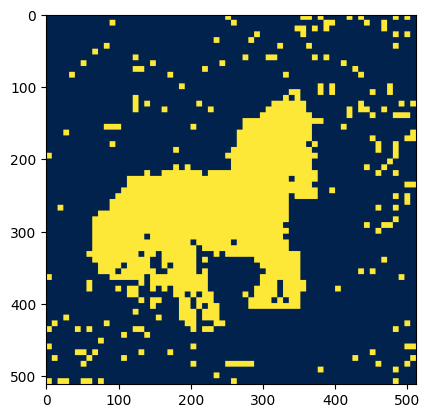

In [ ]:
plot_mask(mask.detach().cpu().numpy()[0, 0])

/tmp/ipython-input-3796185510.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(m).to(device)


  0%|          | 0/49 [00:00<?, ?it/s]

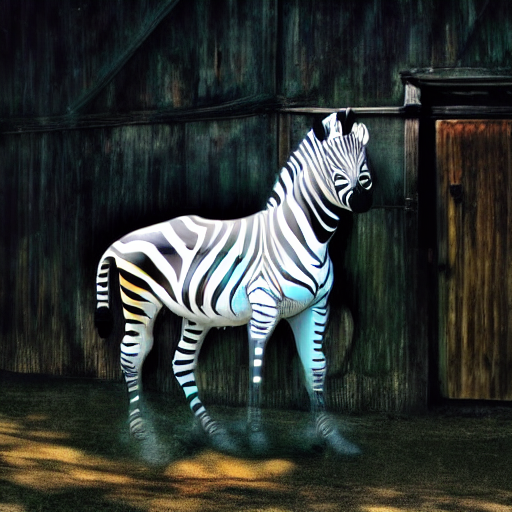

In [ ]:
def diffedit(init_img, rp, qp, strength=0.5, steps=70, seed=100, m=None):
  if m is None:
    mask = create_mask(init_img, rp, qp, n=5, s=strength)
    mask = torch.tensor(mask, device=device)[None, None, ...]
  else:
    mask = torch.tensor(m).to(device)

  edited_ltnt = masked_diffusion(init_img, mask, rp, qp, steps=steps, strength=strength, seed=seed)
  return mask, edited_ltnt

mask, out = diffedit(init_img, ['a horse image'], ['a zebra image'], strength=0.7, seed=100, m=mask)
to_img(out)[0]

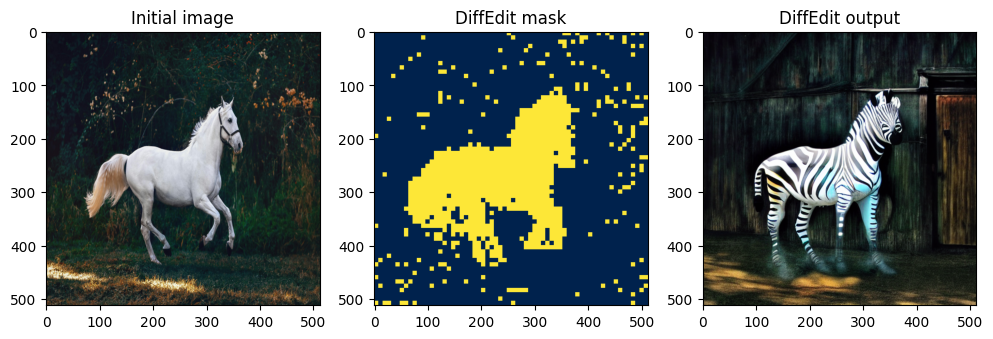

In [ ]:
def plot_edit(init_img, pil_output, mask):
  fig, axs = plt.subplots(1, 3, figsize=(12, 6))

  ## Visualizing initial image
  axs[0].imshow(init_img)
  axs[0].set_title(f"Initial image")

  ## Visualizing initial image
  axs[2].imshow(pil_output[0])
  axs[2].set_title(f"DiffEdit output")

  ## Visualizing the mask
  axs[1].imshow(np.array(init_img), cmap='gray')
  axs[1].imshow(
      Image.fromarray(mask).resize((512,512)), ## Scaling the mask to original size
      cmap='cividis',
      alpha=0.5*(np.array(Image.fromarray(mask*255).resize((512,512))) > 0)
  )
  axs[1].set_title(f"DiffEdit mask")


plot_edit(init_img, to_img(out), mask[0,0].detach().cpu().numpy())

### Can we make it Faster?

Diff edit seems to work well but it takes a while to run, are there any things we can do to make it run faster?

1. Maybe for mask generation, compute difference b/w initial image mapped to a latent and the im2im generation using the query prompt only (means we halve the number of times we call im2im)

2. Another idea is instead of using the full diffusion loop to generate the contrasting latents we can try using the U-net to do one or a few (k) repetitions

3. Use the huggingface `inpaint` pipeline to implement masked diffusion instead of our custom implementation

In [ ]:
# Same as before excpet now we only run the query latent against the original latent
def create_mask2(init_img, qp, n=10, s=0.5):
  orig_ltnt = to_latent(init_img).detach().cpu()
  diffs = []


  for idx in range(n):
    query_ltnt = im2im(init_img, qp, strength=s, seed=100*idx).detach().cpu()
    diffs.append((np.array(orig_ltnt)-np.array(query_ltnt))[0])

  diffs = np.array(diffs)
  abs_diff = np.abs(diffs)
  mask = abs_diff.mean(axis=(0,1)) # Take the mean across n comps and across channels
  mask /= n

  mask = (mask - mask.mean()) / np.std(mask)
  return (mask > 0.5).astype("uint8")

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

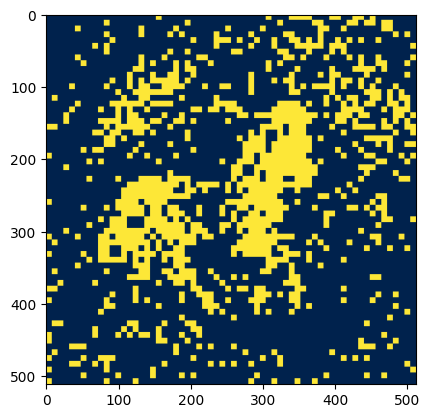

In [ ]:
m2 = create_mask2(init_img, ['a zebra image'], n=15)

plot_mask(m2)

In [ ]:
diff_loop??

In [ ]:
# Looks like the above method doesn't create a good mask, ok
# Let's try the next method of not running the entire diffusion loop

def fast_mask(init_img, rp, qp, k=1, n=20, s=0.5, guidance=7.5):
  diffs = []

  # Use code similar to im2im code
  latent = to_latent(init_img)
  scheduler.set_timesteps(50)
  t_init = int(strength * steps)
  t = torch.tensor([scheduler.timesteps[-t_init]], device=device)
  start = max(steps - t_init, 0)
  timesteps = scheduler.timesteps[start:start+k].to(device)
  rtxt = enc_text(rp)
  qtxt = enc_text(qp)
  uncond = enc_text("")
  remb = torch.cat([uncond, rtxt])
  qemb = torch.cat([uncond, qtxt])

  for idx in tqdm(range(n)):
    torch.manual_seed(100*idx)
    noised_ltnt = scheduler.add_noise(latent, torch.randn_like(latent), t)
    rltnt = noised_ltnt
    qltnt = noised_ltnt

    for i, ts in enumerate(timesteps):
      rltnt = diff_loop(scheduler, rltnt, remb, ts, guidance)
      qltnt = diff_loop(scheduler, qltnt, qemb, ts, guidance)

    d = (rltnt - qltnt)[0]
    diffs.append(d.detach().cpu().numpy())

  diffs = np.array(diffs)
  abs_diff = np.abs(diffs)
  mask = abs_diff.mean(axis=(0,1)) # Take the mean across n comps and across channels
  mask /= n

  print(mask.mean(), np.std(mask))
  mask = (mask - mask.mean()) / np.std(mask)
  return (mask > 0.1).astype("uint8")

m3 = fast_mask(init_img, ['a horse image'], ['a zebra image'], k=1, n=20)

  0%|          | 0/20 [00:00<?, ?it/s]

0.005005 0.002466


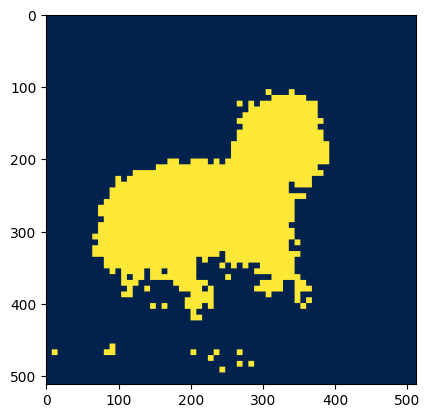

In [ ]:
plot_mask(m3) # This makes a great mask!!!

  0%|          | 0/20 [00:00<?, ?it/s]

0.00501 0.002466


  0%|          | 0/49 [00:00<?, ?it/s]

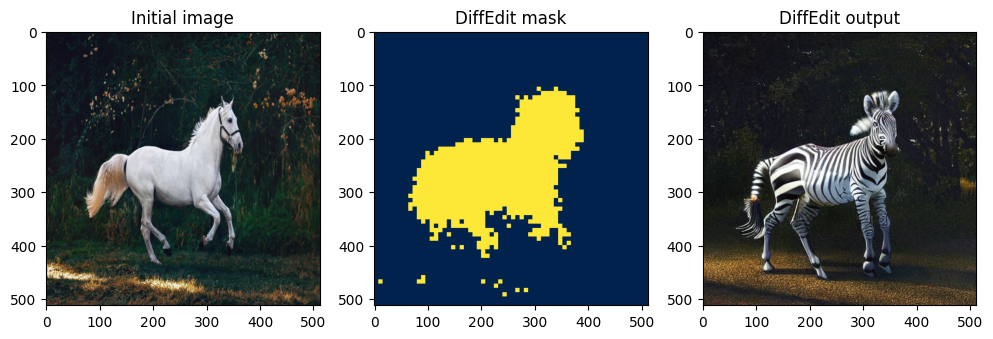

In [ ]:
# Ok now lets put this to use
def fast_diffedit(init_img, rp, qp, strength=0.5, steps=70, seed=100):
  mask = fast_mask(init_img, rp, qp, s=strength)
  mask = torch.tensor(mask, device=device)[None, None, ...]

  edited_ltnt = masked_diffusion(init_img, mask, rp, qp, steps=steps, strength=strength, seed=seed)
  return mask, edited_ltnt

mask, out = fast_diffedit(init_img, ['a horse image'], ['a zebra image'], strength=0.7, seed=100)

plot_edit(init_img, to_img(out), mask[0,0].detach().cpu().numpy())

In [ ]:
def create_mask(init_img, rp, qp, n=10, s=0.5):
    ## Initialize a dictionary to save n iterations
    diffs = []

    ## Repeating the difference process n times
    for idx in range(n):
      # NOTE: really important that the seed for the im2im of both of these is the same
      # This ensures that the "seed" or starting point of them is both the same so that their differences
      # ONLY have to do with the different text conditioning and not the random noise being different
        ## Creating denoised sample using reference / original text
        orig_noise = im2im(init_img, rp, strength=s, seed = 100*idx)[0].detach().cpu()
        ## Creating denoised sample using query / target text
        query_noise = im2im(init_img, qp, strength=s, seed = 100*idx)[0].detach().cpu()
        ## Taking the difference
        diffs.append(np.array(orig_noise)-np.array(query_noise))

    ## Creating a mask placeholder
    mask = np.zeros_like(diffs[0])

    ## Taking an average of 10 iterations
    for idx in range(n):
        ## Note np.abs is a key step
        mask += np.abs(diffs[idx]) # add the absolute difference s.t. when we filter the mask only keeps cell with positive abs diff
    mask /= n

    ## Averaging multiple channels
    mask = mask.mean(0)

    ## Normalizing
    mask = (mask - mask.mean()) / np.std(mask)

    ## Binarizing and returning the mask object
    return (mask > 0.2).astype("uint8")